In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
rfm = pd.read_csv("/content/sample_data/rfm_data.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [4]:
X = rfm[["Recency", "Frequency", "Monetary"]]

X.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [39]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [52]:
dbscan = DBSCAN(eps=0.6, min_samples=8)
clusters = dbscan.fit_predict(X_scaled)
rfm["Cluster"] = clusters

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,-1
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,0
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,0


In [53]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,4284
-1,49
1,5


In [54]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
noise_points = list(clusters).count(-1)
print("Number of Clusters :", n_clusters)

print("Noise Points :", noise_points)

Number of Clusters : 2
Noise Points : 49


In [57]:
cluster_profile = (rfm.groupby("Cluster") [["Recency","Frequency","Monetary"]].mean().round(2))

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
-1,40.16,44.94,58369.24
0,93.24,3.77,1398.25
1,2.60,37.40,7400.41


In [58]:
if n_clusters > 1:

    score = silhouette_score(X_scaled, clusters)

    print("Silhouette Score:", round(score,4))

else:

    print("Silhouette Score cannot be calculated.")

Silhouette Score: 0.6874


In [59]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [60]:
pca_df = pd.DataFrame( X_pca, columns=["PC1","PC2"])

pca_df["Cluster"] = clusters

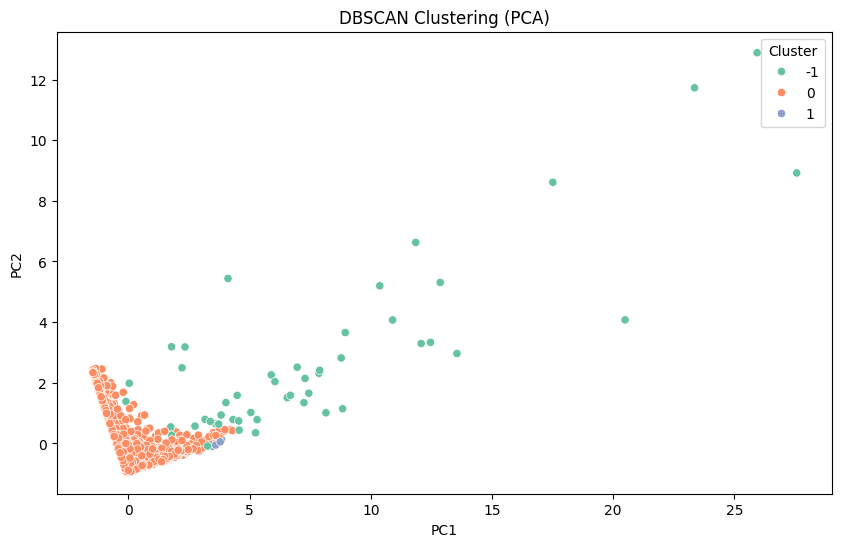

In [61]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Cluster",palette="Set2")
plt.title("DBSCAN Clustering (PCA)")

plt.show()

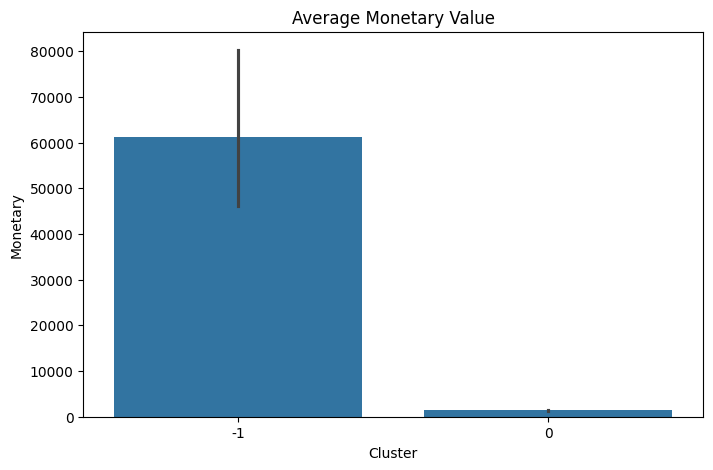

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rfm,
    x="Cluster",
    y="Monetary"
)

plt.title("Average Monetary Value")

plt.show()

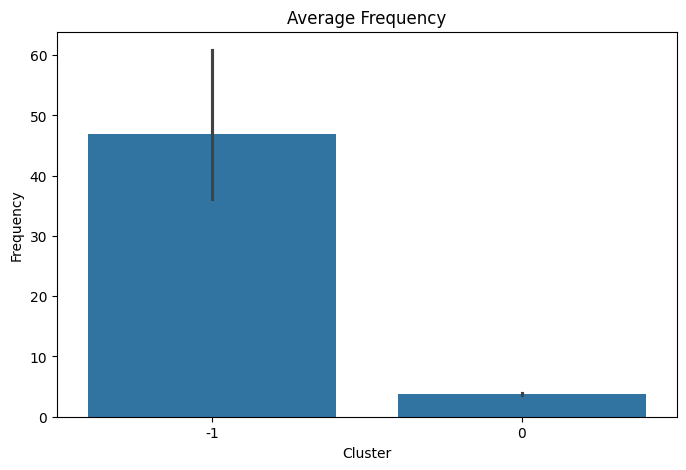

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rfm,
    x="Cluster",
    y="Frequency"
)

plt.title("Average Frequency")

plt.show()

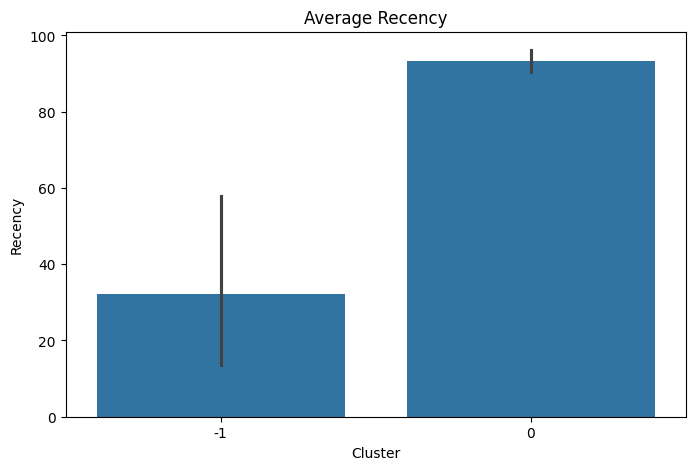

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rfm,
    x="Cluster",
    y="Recency"
)

plt.title("Average Recency")

plt.show()

 ## Observation

DBSCAN automatically identifies clusters based on density and labels outliers as noise.

Unlike K-Means and Hierarchical Clustering, DBSCAN does not require specifying the number of clusters in advance.

The clustering results are highly dependent on the values of **eps** and **min_samples**.




## Conclusion

DBSCAN is effective for detecting outliers and identifying clusters of arbitrary shapes.

However, on the RFM customer dataset, clustering quality depends heavily on parameter tuning.

The results will be compared with K-Means and Hierarchical Clustering in the next notebook.